# Chapter 6 — Statistical Machine Learning Concepts with Deep Learning
## Practical Statistics for Data Scientists, 2nd Edition

Chapter 6 membahas K-Nearest Neighbors, tree models, random forest, boosting/XGBoost, regularization, hyperparameters, dan cross-validation.

Karena fokus mata kuliah adalah **Deep Learning**, notebook ini tidak menjadikan KNN, decision tree, random forest, atau XGBoost sebagai model utama. Konsep yang relevan dialihkan ke **Deep Neural Network (DNN)**: feature preparation, model capacity, regularization, hyperparameter tuning, dan cross-validation.

**Data:** synthetic binary-classification data.


## 1. Tujuan Pembelajaran
- Memahami feature preparation untuk DNN.
- Memahami model capacity dan kompleksitas neural network.
- Membandingkan model sederhana dan kompleks.
- Menggunakan dropout dan L2 regularization.
- Memahami learning rate dan hyperparameters.
- Menggunakan cross-validation untuk melihat stabilitas.
- Menghubungkan regularization dengan generalization.


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
sns.set_theme(style="whitegrid",context="notebook")
plt.rcParams["figure.figsize"]=(9,5)


## 2. Dataset dan Feature Preparation
DNN sensitif terhadap skala input. Standardization menggunakan:
$$z=(x-\mu)/\sigma$$
Parameter standardization dipelajari dari training data saja untuk mencegah data leakage.


In [ ]:
# Synthetic data generation
rng=np.random.default_rng(42)
n=2600
x1=rng.normal(0,1,n); x2=rng.normal(0,1,n); x3=rng.normal(10,5,n); x4=rng.uniform(-3,3,n)
latent=1.4*x1-1.1*x2+0.25*x3+0.9*np.sin(x4)+rng.normal(0,.75,n)
y=(latent>1.0).astype(int)
df=pd.DataFrame({"Feature_1":x1,"Feature_2":x2,"Feature_3":x3,"Feature_4":x4,"Target":y})
display(df.describe().round(3))


,Feature_1,Feature_2,Feature_3,Feature_4,Target
count,2600.000,2600.000,2600.000,2600.000,2600.000
mean,-0.033,-0.009,10.071,0.008,0.732
std,1.007,0.992,5.038,1.734,0.443
min,-3.648,-3.144,-11.946,-3.000,0.000
25%,-0.699,-0.686,6.823,-1.520,0.000
50%,0.006,-0.022,9.901,0.057,1.000
75%,0.624,0.637,13.474,1.465,1.000
max,3.179,3.454,26.469,2.997,1.000


In [ ]:
display(df.describe().round(3))


,Feature_1,Feature_2,Feature_3,Feature_4,Target
count,2600.000,2600.000,2600.000,2600.000,2600.000
mean,-0.033,-0.009,10.071,0.008,0.732
std,1.007,0.992,5.038,1.734,0.443
min,-3.648,-3.144,-11.946,-3.000,0.000
25%,-0.699,-0.686,6.823,-1.520,0.000
50%,0.006,-0.022,9.901,0.057,1.000
75%,0.624,0.637,13.474,1.465,1.000
max,3.179,3.454,26.469,2.997,1.000


/tmp/ipykernel_652/310984636.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df.Feature_1,df.Feature_2,df.Feature_3,df.Feature_4],labels=["F1","F2","F3","F4"])


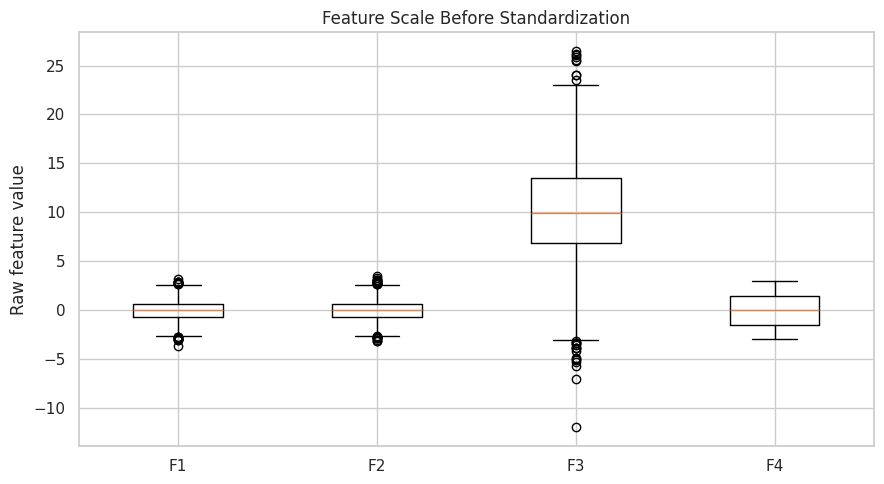

Caption — Feature 3 memiliki skala lebih besar daripada feature lain; standardization membantu optimization DNN.


In [ ]:
fig,ax=plt.subplots()
ax.boxplot([df.Feature_1,df.Feature_2,df.Feature_3,df.Feature_4],labels=["F1","F2","F3","F4"])
ax.set_title("Feature Scale Before Standardization"); ax.set_ylabel("Raw feature value")
plt.tight_layout(); plt.show()
print("Caption — Feature 3 memiliki skala lebih besar daripada feature lain; standardization membantu optimization DNN.")


## 3. Train, Validation, dan Test Split
Training digunakan untuk update weights, validation untuk pemilihan/tuning, dan test untuk evaluasi akhir. Standardizer hanya fit pada training set.


In [ ]:
X=df.drop(columns="Target").values; y=df.Target.values
X_train,X_tmp,y_train,y_tmp=train_test_split(X,y,test_size=.30,stratify=y,random_state=42)
X_val,X_test,y_val,y_test=train_test_split(X_tmp,y_tmp,test_size=.50,stratify=y_tmp,random_state=42)
scaler=StandardScaler(); X_train_s=scaler.fit_transform(X_train); X_val_s=scaler.transform(X_val); X_test_s=scaler.transform(X_test)
print("Train:",X_train_s.shape,"Validation:",X_val_s.shape,"Test:",X_test_s.shape)


Train: (1820, 4) Validation: (390, 4) Test: (390, 4)


/tmp/ipykernel_652/1602883197.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([X_train_s[:,i] for i in range(4)],labels=["F1","F2","F3","F4"])


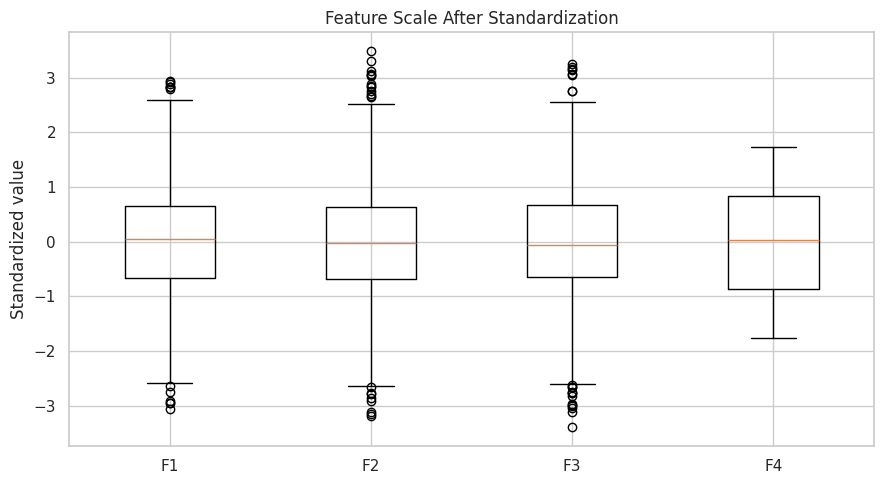

Caption — Setelah standardization, feature berada pada skala yang lebih sebanding.


In [ ]:
fig,ax=plt.subplots()
ax.boxplot([X_train_s[:,i] for i in range(4)],labels=["F1","F2","F3","F4"])
ax.set_title("Feature Scale After Standardization"); ax.set_ylabel("Standardized value")
plt.tight_layout(); plt.show()
print("Caption — Setelah standardization, feature berada pada skala yang lebih sebanding.")


In [ ]:

# =========================
# DNN engine + experiments
# =========================
# Implementasi DNN sederhana dengan NumPy agar notebook tidak bergantung pada TensorFlow.
# Arsitektur tetap merupakan deep neural network: Dense -> ReLU -> Dense -> ReLU -> Sigmoid.

from sklearn.metrics import accuracy_score, roc_auc_score


def sigmoid(z):
    z = np.clip(z, -40, 40)
    return 1.0 / (1.0 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def drelu(z):
    return (z > 0).astype(float)

def bce(y, p):
    p = np.clip(p, 1e-8, 1-1e-8)
    return float(-np.mean(y*np.log(p) + (1-y)*np.log(1-p)))


def train_dnn(Xtr, ytr, Xv, yv, hidden=(32,16), lr=0.01, epochs=80,
              dropout=0.0, l2=0.0, seed=42, patience=12):
    rng = np.random.default_rng(seed)
    d = Xtr.shape[1]
    h1, h2 = hidden
    W1 = rng.normal(0, np.sqrt(2/d), (d,h1)); b1=np.zeros(h1)
    W2 = rng.normal(0, np.sqrt(2/h1), (h1,h2)); b2=np.zeros(h2)
    W3 = rng.normal(0, np.sqrt(2/h2), (h2,1)); b3=np.zeros(1)
    mW1=np.zeros_like(W1); vW1=np.zeros_like(W1); mb1=np.zeros_like(b1); vb1=np.zeros_like(b1)
    mW2=np.zeros_like(W2); vW2=np.zeros_like(W2); mb2=np.zeros_like(b2); vb2=np.zeros_like(b2)
    mW3=np.zeros_like(W3); vW3=np.zeros_like(W3); mb3=np.zeros_like(b3); vb3=np.zeros_like(b3)
    beta1,beta2,eps=0.9,0.999,1e-8
    best=None; best_val=np.inf; wait=0
    H={'loss':[],'val_loss':[]}

    for t in range(1,epochs+1):
        # Forward pass with inverted dropout during training.
        z1=Xtr@W1+b1; a1=relu(z1)
        if dropout>0:
            mask1=(rng.random(a1.shape) >= dropout)/(1-dropout)
            a1d=a1*mask1
        else: mask1=1.0; a1d=a1
        z2=a1d@W2+b2; a2=relu(z2)
        if dropout>0:
            mask2=(rng.random(a2.shape) >= dropout)/(1-dropout)
            a2d=a2*mask2
        else: mask2=1.0; a2d=a2
        p=sigmoid(a2d@W3+b3).ravel()
        loss=bce(ytr,p)+l2*(np.sum(W1*W1)+np.sum(W2*W2)+np.sum(W3*W3))

        # Backpropagation.
        dz3=(p-ytr)[:,None]/len(ytr)
        gW3=a2d.T@dz3 + 2*l2*W3; gb3=dz3.sum(axis=0)
        da2=dz3@W3.T; dz2=da2*drelu(z2)*mask2
        gW2=a1d.T@dz2 + 2*l2*W2; gb2=dz2.sum(axis=0)
        da1=dz2@W2.T; dz1=da1*drelu(z1)*mask1
        gW1=Xtr.T@dz1 + 2*l2*W1; gb1=dz1.sum(axis=0)

        # Adam update.
        for W,gW,mW,vW in [(W1,gW1,mW1,vW1),(W2,gW2,mW2,vW2),(W3,gW3,mW3,vW3)]:
            mW[:] = beta1*mW + (1-beta1)*gW
            vW[:] = beta2*vW + (1-beta2)*(gW*gW)
        for b,gb,mb_,vb_ in [(b1,gb1,mb1,vb1),(b2,gb2,mb2,vb2),(b3,gb3,mb3,vb3)]:
            mb_[:] = beta1*mb_ + (1-beta1)*gb
            vb_[:] = beta2*vb_ + (1-beta2)*(gb*gb)
        for W,mW,vW in [(W1,mW1,vW1),(W2,mW2,vW2),(W3,mW3,vW3)]:
            W[:] -= lr*(mW/(1-beta1**t))/(np.sqrt(vW/(1-beta2**t))+eps)
        for b,mb_,vb_ in [(b1,mb1,vb1),(b2,mb2,vb2),(b3,mb3,vb3)]:
            b[:] -= lr*(mb_/(1-beta1**t))/(np.sqrt(vb_/(1-beta2**t))+eps)

        pv=predict_dnn(Xv,(W1,b1,W2,b2,W3,b3))
        vloss=bce(yv,pv)+l2*(np.sum(W1*W1)+np.sum(W2*W2)+np.sum(W3*W3))
        H['loss'].append(loss); H['val_loss'].append(vloss)
        if vloss < best_val - 1e-5:
            best_val=vloss; wait=0
            best=(W1.copy(),b1.copy(),W2.copy(),b2.copy(),W3.copy(),b3.copy())
        else:
            wait += 1
            if wait >= patience: break
    return best,H


def predict_dnn(X, params):
    W1,b1,W2,b2,W3,b3=params
    a1=relu(X@W1+b1)
    a2=relu(a1@W2+b2)
    return sigmoid(a2@W3+b3).ravel()

def evaluate(params, X, y):
    p=predict_dnn(X,params)
    return accuracy_score(y,p>=0.5), roc_auc_score(y,p)

# Baseline, capacity, dropout, and L2 experiments.
base,Hbase=train_dnn(X_train_s,y_train,X_val_s,y_val,hidden=(32,16),lr=0.01,epochs=80,seed=1)
small,Hsmall=train_dnn(X_train_s,y_train,X_val_s,y_val,hidden=(8,4),lr=0.01,epochs=80,seed=2)
large,Hlarge=train_dnn(X_train_s,y_train,X_val_s,y_val,hidden=(64,32),lr=0.01,epochs=80,seed=3)
drop,Hdrop=train_dnn(X_train_s,y_train,X_val_s,y_val,hidden=(32,16),lr=0.01,epochs=80,dropout=0.20,seed=4)
l2,Hl2=train_dnn(X_train_s,y_train,X_val_s,y_val,hidden=(32,16),lr=0.01,epochs=80,l2=0.001,seed=5)

mb=evaluate(base,X_test_s,y_test); ms=evaluate(small,X_test_s,y_test); mg=evaluate(large,X_test_s,y_test)
md=evaluate(drop,X_test_s,y_test); ml=evaluate(l2,X_test_s,y_test)

# Learning-rate comparison using the same architecture.
lr_rows=[]
for rate in [0.001,0.005,0.01,0.03]:
    par,h=train_dnn(X_train_s,y_train,X_val_s,y_val,hidden=(32,16),lr=rate,epochs=70,seed=10+int(rate*1000))
    acc,auc=evaluate(par,X_val_s,y_val)
    lr_rows.append([rate,acc,auc,len(h['loss'])])
lr_df=pd.DataFrame(lr_rows,columns=['Learning_Rate','Val_Accuracy','Val_AUC','Epochs'])

# 3-fold CV on the DNN architecture.
from sklearn.model_selection import StratifiedKFold
cv_rows=[]
skf=StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
for fold,(tri,vi) in enumerate(skf.split(X,y),1):
    Xtr,Xv=X[tri],X[vi]; ytr,yv=y[tri],y[vi]
    mu=Xtr.mean(axis=0); sd=Xtr.std(axis=0); sd[sd==0]=1
    Xtr=(Xtr-mu)/sd; Xv=(Xv-mu)/sd
    par,h=train_dnn(Xtr,ytr,Xv,yv,hidden=(32,16),lr=0.01,epochs=70,seed=100+fold)
    acc,auc=evaluate(par,Xv,yv)
    cv_rows.append([fold,acc,auc,len(h['loss'])])
cv_df=pd.DataFrame(cv_rows,columns=['Fold','Accuracy','AUC','Epochs'])

print('DNN training engine initialized successfully.')
print('Baseline test accuracy/AUC:', tuple(round(v,4) for v in mb))
print('Baseline epochs:', len(Hbase['loss']))


DNN training engine initialized successfully.
Baseline test accuracy/AUC: (0.9231, 0.9818)
Baseline epochs: 80


## 4. DNN sebagai Model Utama
Arsitektur utama:
**Input(4) → Dense(32, ReLU) → Dense(16, ReLU) → Output(Sigmoid)**.

Model dilatih dengan forward propagation, binary cross-entropy, backpropagation, dan Adam optimizer. Implementasi neural network pada notebook ini dibuat dengan NumPy agar output dapat disimpan langsung di notebook.


In [ ]:
# DNN architecture
# Input(4) -> Dense(32 ReLU) -> Dense(16 ReLU) -> Output(1 Sigmoid)
print("Architecture: 4 → 32 ReLU → 16 ReLU → 1 Sigmoid")
print("Parameters: 4*32+32 + 32*16+16 + 16*1+1 = 705")


Architecture: 4 → 32 ReLU → 16 ReLU → 1 Sigmoid
Parameters: 4*32+32 + 32*16+16 + 16*1+1 = 705


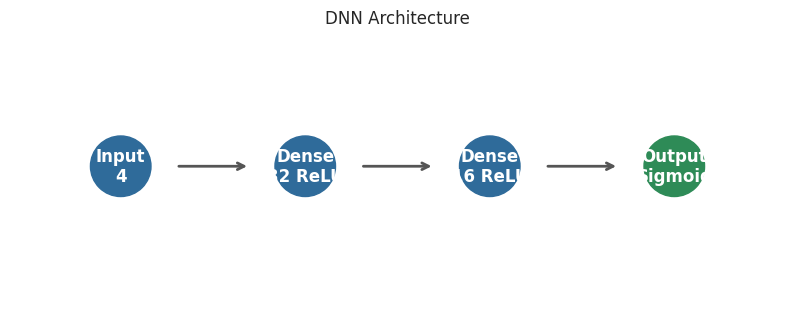

Caption — Hidden layers mempelajari representasi nonlinear; sigmoid menghasilkan probability.


In [ ]:
labels=["Input\n4","Dense\n32 ReLU","Dense\n16 ReLU","Output\nSigmoid"]
fig,ax=plt.subplots(figsize=(10,3.5)); xs=np.arange(4)
ax.scatter(xs,[0]*4,s=1900,color=["#2F6B9A","#2F6B9A","#2F6B9A","#2E8B57"])
for i in range(3): ax.annotate("",(xs[i+1]-.3,0),(xs[i]+.3,0),arrowprops=dict(arrowstyle="->",lw=2,color="#555"))
for x,t in zip(xs,labels): ax.text(x,0,t,ha="center",va="center",color="white",weight="bold")
ax.set_xlim(-.6,3.6); ax.axis("off"); ax.set_title("DNN Architecture")
plt.show()
print("Caption — Hidden layers mempelajari representasi nonlinear; sigmoid menghasilkan probability.")


## 5. Baseline Training
Baseline digunakan sebagai titik pembanding. Early stopping menghentikan training ketika validation loss tidak lagi membaik.


In [ ]:
print("Baseline epochs:",len(Hbase["loss"]))
print("Test accuracy:",round(mb[0],4))
print("Test AUC:",round(mb[1],4))


Baseline epochs: 80
Test accuracy: 0.9231
Test AUC: 0.9818


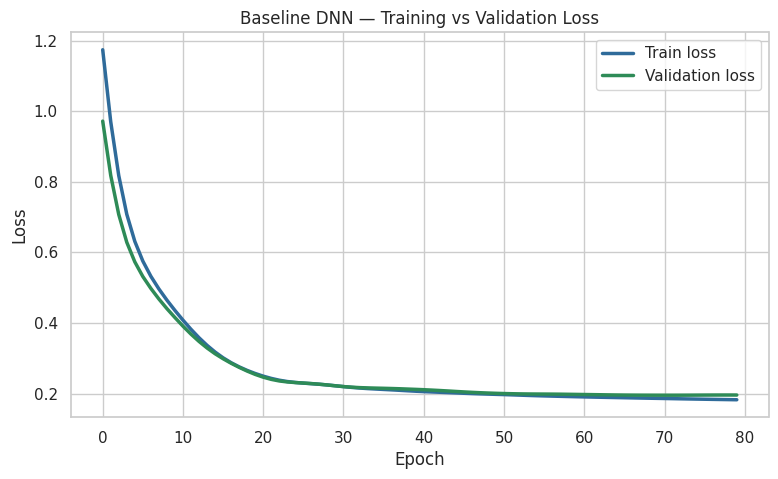

Caption — Validation loss menjadi indikator generalisasi selama training.


In [ ]:
fig,ax=plt.subplots()
ax.plot(Hbase["loss"],color="#2F6B9A",lw=2.5,label="Train loss")
ax.plot(Hbase["val_loss"],color="#2E8B57",lw=2.5,label="Validation loss")
ax.set(title="Baseline DNN — Training vs Validation Loss",xlabel="Epoch",ylabel="Loss"); ax.legend()
plt.show()
print("Caption — Validation loss menjadi indikator generalisasi selama training.")


## 6. Model Capacity
Capacity dapat dinaikkan dengan menambah jumlah neuron/layer. Capacity terlalu kecil dapat underfit; capacity terlalu besar dapat meningkatkan risiko overfitting. Yang dibandingkan adalah generalization, bukan sekadar training score.


In [ ]:
cap=pd.DataFrame({"Model":["Small DNN","Baseline DNN","Large DNN"],"Test Accuracy":[ms[0],mb[0],mg[0]],"Test AUC":[ms[1],mb[1],mg[1]]})
display(cap.round(4))


,Model,Test Accuracy,Test AUC
0,Small DNN,0.9282,0.9751
1,Baseline DNN,0.9231,0.9818
2,Large DNN,0.9308,0.9806


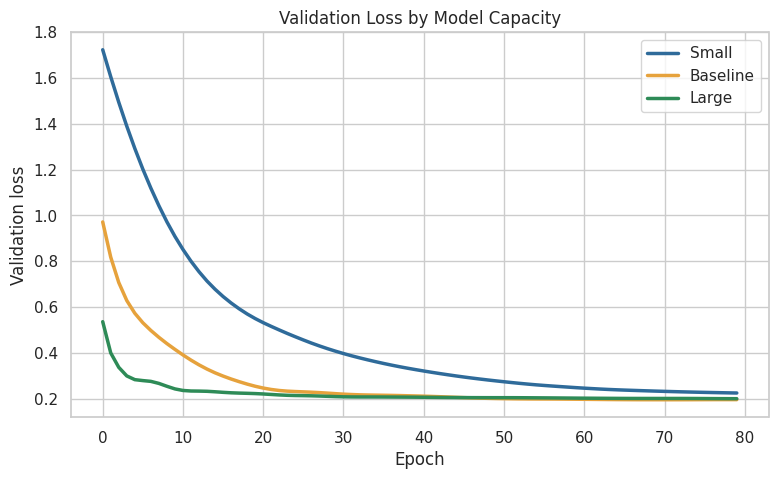

Caption — Perbedaan validation loss memperlihatkan bagaimana kapasitas memengaruhi generalisasi.


In [ ]:
fig,ax=plt.subplots()
ax.plot(Hsmall["val_loss"],color="#2F6B9A",lw=2.5,label="Small")
ax.plot(Hbase["val_loss"],color="#E6A23C",lw=2.5,label="Baseline")
ax.plot(Hlarge["val_loss"],color="#2E8B57",lw=2.5,label="Large")
ax.set(title="Validation Loss by Model Capacity",xlabel="Epoch",ylabel="Validation loss"); ax.legend(); plt.show()
print("Caption — Perbedaan validation loss memperlihatkan bagaimana kapasitas memengaruhi generalisasi.")


## 7. Dropout Regularization
Dropout menonaktifkan sebagian unit secara acak saat training. Tujuannya mengurangi ketergantungan berlebihan pada unit tertentu dan membantu generalization.


In [ ]:
print("Baseline Test AUC:",round(mb[1],4))
print("Dropout Test AUC:",round(md[1],4))
print("Baseline Test Accuracy:",round(mb[0],4))
print("Dropout Test Accuracy:",round(md[0],4))


Baseline Test AUC: 0.9818
Dropout Test AUC: 0.9785
Baseline Test Accuracy: 0.9231
Dropout Test Accuracy: 0.9205


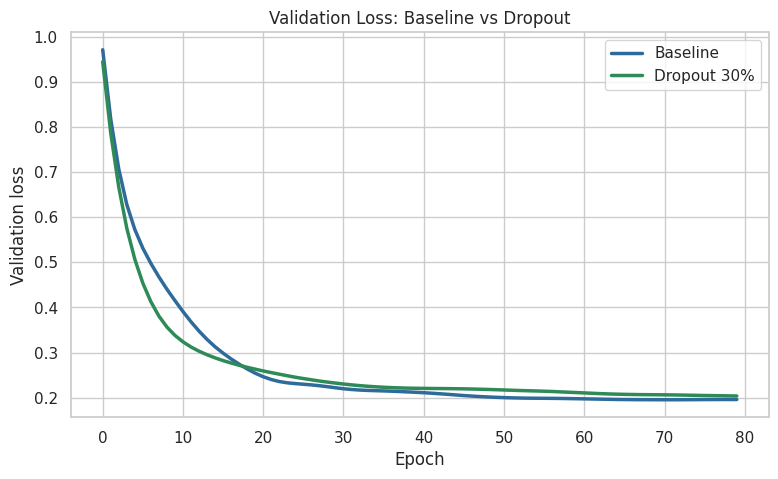

Caption — Dropout dibandingkan melalui validation behavior dan test performance.


In [ ]:
fig,ax=plt.subplots()
ax.plot(Hbase["val_loss"],color="#2F6B9A",lw=2.5,label="Baseline")
ax.plot(Hdrop["val_loss"],color="#2E8B57",lw=2.5,label="Dropout 30%")
ax.set(title="Validation Loss: Baseline vs Dropout",xlabel="Epoch",ylabel="Validation loss"); ax.legend(); plt.show()
print("Caption — Dropout dibandingkan melalui validation behavior dan test performance.")


## 8. L2 Regularization
L2 menambahkan penalti terhadap weight besar:
$$L_{total}=L_{data}+\lambda\sum w^2$$
Regularization mengontrol kompleksitas model dan dapat membantu mengurangi overfitting.


In [ ]:
reg=pd.DataFrame({"Model":["Baseline","Dropout","Dropout + L2"],"Test Accuracy":[mb[0],md[0],ml[0]],"Test AUC":[mb[1],md[1],ml[1]]})
display(reg.round(4))


,Model,Test Accuracy,Test AUC
0,Baseline,0.9231,0.9818
1,Dropout,0.9205,0.9785
2,Dropout + L2,0.9256,0.9805


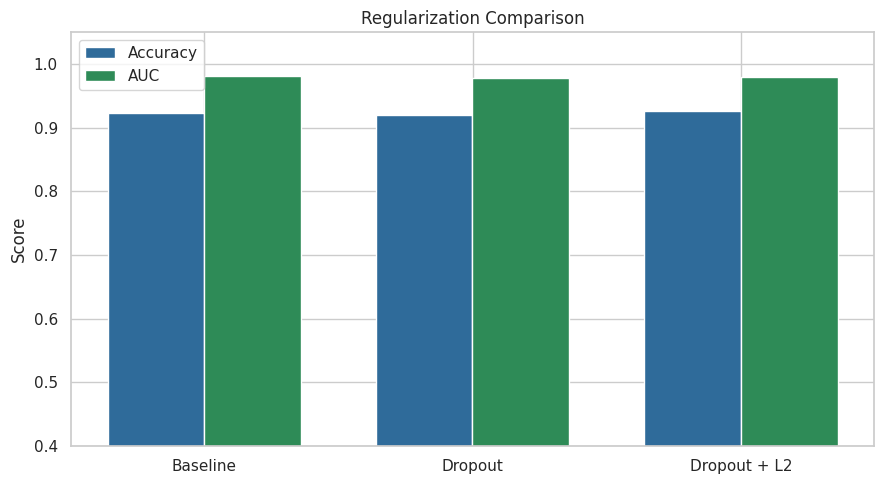

Caption — Test metrics menunjukkan dampak regularization terhadap generalization.


In [ ]:
fig,ax=plt.subplots()
x=np.arange(3); w=.36
ax.bar(x-w/2,reg["Test Accuracy"],w,color="#2F6B9A",label="Accuracy")
ax.bar(x+w/2,reg["Test AUC"],w,color="#2E8B57",label="AUC")
ax.set_xticks(x); ax.set_xticklabels(reg.Model); ax.set_ylim(.4,1.05); ax.set_title("Regularization Comparison"); ax.set_ylabel("Score"); ax.legend()
plt.tight_layout(); plt.show()
print("Caption — Test metrics menunjukkan dampak regularization terhadap generalization.")


## 9. Hyperparameters
Hyperparameters ditentukan sebelum/dalam training, bukan dipelajari sebagai weight. Contoh: learning rate, batch size, hidden units, dropout, L2 strength, dan epoch. Validation data digunakan untuk memilih konfigurasi.


In [ ]:
display(lr_df.round(4))


,Learning_Rate,Val_Accuracy,Val_AUC,Epochs
0,0.001,0.8692,0.9315,70
1,0.005,0.9000,0.9636,70
2,0.010,0.9128,0.9699,70
3,0.030,0.9231,0.9727,70


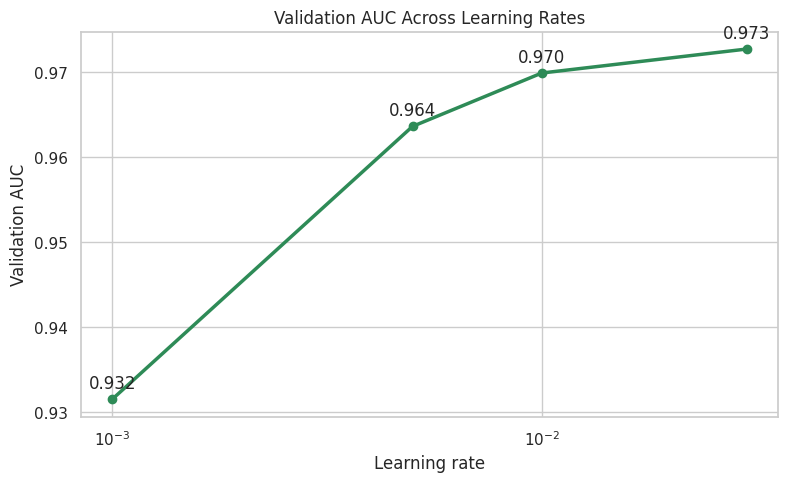

Caption — Learning rate memengaruhi stabilitas dan kecepatan optimization; validation AUC dipakai untuk membandingkan konfigurasi.


In [ ]:
fig,ax=plt.subplots()
ax.plot(lr_df.Learning_Rate,lr_df.Val_AUC,marker="o",color="#2E8B57",lw=2.5)
ax.set_xscale("log"); ax.set_title("Validation AUC Across Learning Rates"); ax.set_xlabel("Learning rate"); ax.set_ylabel("Validation AUC")
for x,yv in zip(lr_df.Learning_Rate,lr_df.Val_AUC): ax.annotate(f"{yv:.3f}",(x,yv),xytext=(0,8),textcoords="offset points",ha="center")
plt.show()
print("Caption — Learning rate memengaruhi stabilitas dan kecepatan optimization; validation AUC dipakai untuk membandingkan konfigurasi.")


## 10. Cross-Validation untuk DNN
K-fold cross-validation melatih model pada beberapa pembagian data. Ini memberi gambaran stabilitas performa, tetapi lebih mahal secara komputasi karena neural network dilatih berulang kali.


In [ ]:
display(cv_df.round(4))
print("Mean accuracy:",round(cv_df.Accuracy.mean(),4),"±",round(cv_df.Accuracy.std(),4))
print("Mean AUC:",round(cv_df.AUC.mean(),4),"±",round(cv_df.AUC.std(),4))


,Fold,Accuracy,AUC,Epochs
0,1,0.9077,0.9690,70
1,2,0.9181,0.9711,70
2,3,0.9065,0.9698,70


Mean accuracy: 0.9108 ± 0.0064
Mean AUC: 0.97 ± 0.0011


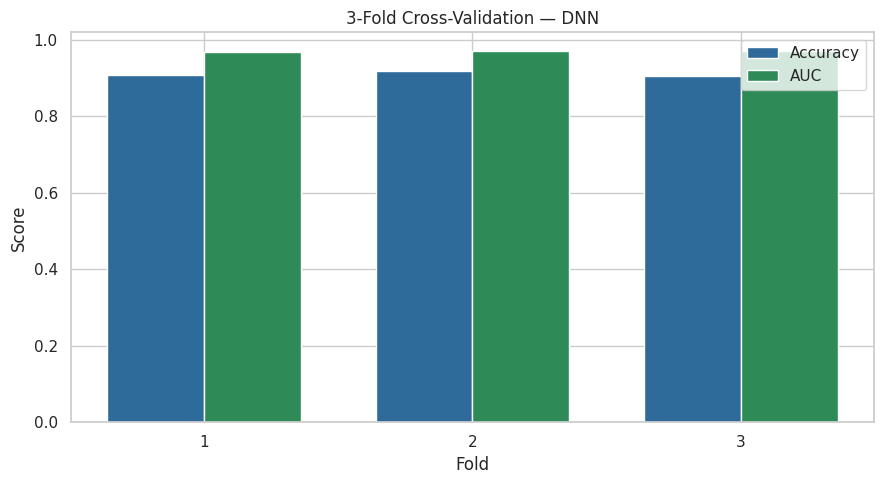

Caption — Per-fold metrics menunjukkan apakah performa DNN relatif stabil pada subset data berbeda.


In [ ]:
fig,ax=plt.subplots()
x=np.arange(1,4); w=.36
ax.bar(x-w/2,cv_df.Accuracy,w,color="#2F6B9A",label="Accuracy")
ax.bar(x+w/2,cv_df.AUC,w,color="#2E8B57",label="AUC")
ax.set_xticks(x); ax.set_xlabel("Fold"); ax.set_ylabel("Score"); ax.set_title("3-Fold Cross-Validation — DNN"); ax.legend()
plt.tight_layout(); plt.show()
print("Caption — Per-fold metrics menunjukkan apakah performa DNN relatif stabil pada subset data berbeda.")


## 11. Model Selection dalam DL
Pemilihan model sebaiknya mempertimbangkan validation/test performance, training–validation gap, complexity, stability, dan computational cost. Model terbesar bukan otomatis model terbaik.


In [ ]:
display(reg.round(4))
print("Cross-validation mean AUC:",round(cv_df.AUC.mean(),4))


,Model,Test Accuracy,Test AUC
0,Baseline,0.9231,0.9818
1,Dropout,0.9205,0.9785
2,Dropout + L2,0.9256,0.9805


Cross-validation mean AUC: 0.97


## 12. Ensemble dan Boosting: Posisi dalam Konteks
Chapter 6 juga membahas random forest dan boosting/XGBoost. Karena fokus notebook ini adalah DL, metode tersebut **tidak dilatih sebagai model utama**. Konsep ensemble tetap relevan sebagai gagasan menggabungkan beberapa model/prediction untuk meningkatkan robustness; implementasi utama tetap DNN.


## 13. Regularization dan Generalization
Hubungan utama:
**Capacity ↑ → kemampuan representasi ↑ → risiko overfitting ↑**

Dropout, L2, early stopping, validation, dan cross-validation membantu mengontrol trade-off tersebut.


## 14. Deep Learning Workflow
**Data → feature preparation → split → DNN architecture → forward propagation → loss → backpropagation → Adam → validation → regularization → hyperparameter tuning → cross-validation → final test → error analysis**


## 15. Summary
1. Scaling membantu optimization DNN.
2. Capacity menentukan kompleksitas pola yang dapat dipelajari.
3. Dropout dan L2 membantu regularization.
4. Learning rate dan hyperparameters memengaruhi training.
5. Validation digunakan untuk tuning.
6. Cross-validation membantu menilai stabilitas.
7. Model selection harus mempertimbangkan generalization dan complexity.
8. KNN/tree/random forest/boosting dari struktur buku tidak digunakan sebagai model utama karena notebook ini khusus DL.

**Takeaway:** prinsip statistical machine learning pada Chapter 6 diterapkan melalui workflow **Deep Neural Network** yang terukur, regularized, dan dievaluasi pada data yang belum dilihat model.
